In [28]:
# Amplitude encoding with a large vector
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation

In [29]:
sample_dan_sequence = pd.read_csv(r'C:\Users\iamin\OneDrive\Documents\Academic\Personal Website\github_page_clone\quantum-computing\project_codes\sample_dna_encoded_matrix.csv')

In [30]:
print(sample_dan_sequence.head())
first_row = sample_dan_sequence.iloc[0, 1:].values.astype(float)

     0    1    2    3    4    5    6    7    8    9  ...  56542  56543  56544  \
0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  1.0  0.0  ...    0.0    0.0    0.0   
1  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  1.0  0.0  ...    0.0    0.0    0.0   
2  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  1.0  0.0  ...    0.0    0.0    0.0   
3  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  1.0  0.0  ...    0.0    0.0    0.0   
4  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0  1.0  0.0  ...    0.0    0.0    0.0   

   56545  56546  56547  56548  56549  56550  56551  
0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
1    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
2    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
3    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
4    0.0    0.0    0.0    0.0    0.0    0.0    0.0  

[5 rows x 56552 columns]


In [ ]:
def pad_to_power_of_2(data):
    """Pad data with zeros to the nearest power of 2"""
    next_power = 2 ** int(np.ceil(np.log2(len(data))))
    padded_data = np.zeros(next_power)
    padded_data[:len(data)] = data  # Retaining original values
    return padded_data

In [35]:
padded_data = pad_to_power_of_2(first_row)

In [ ]:
vector = padded_data  # Using the papped first row of the dataset as the vector
qbits = list(np.arange(int(np.log2(len(vector)))))  # Number of qubits for the circuit
vector /= np.linalg.norm(vector)  # Normalize explicitly

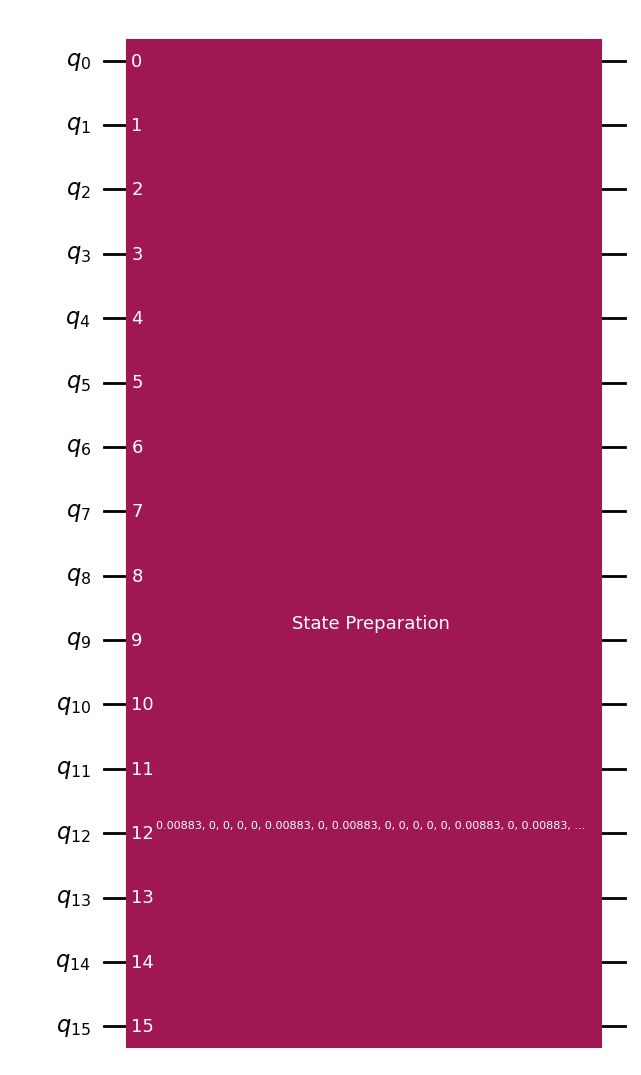

In [ ]:
qc = QuantumCircuit(len(qbits))
qc.append(StatePreparation(vector), qbits)
display(qc.draw(output="mpl"))

In [ ]:
# from qiskit.circuit.library import ZZFeatureMap

# # Create ZZFeatureMap with the same number of features
# feature_map = ZZFeatureMap(feature_dimension=len(vector), reps=1)

# # Assign feature values to the parameterized circuit
# qc = feature_map.assign_parameters(vector)

# # Draw the circuit
# qc.draw(output="mpl")


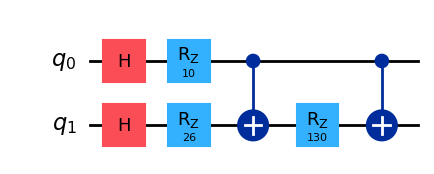

In [39]:
from qiskit import QuantumCircuit
import numpy as np

# Define feature values
x1, x2 = 5, 13

# Create a 2-qubit quantum circuit
qc = QuantumCircuit(2)

# 1. Apply Hadamard gates to create superposition
qc.h([0, 1])

# 2. Apply RZ rotations to encode feature values
qc.rz(2 * x1, 0)  # RZ(2*x1) on qubit 0
qc.rz(2 * x2, 1)  # RZ(2*x2) on qubit 1

# 3. Apply entangling ZZ feature interaction
qc.cx(0, 1)  # CNOT(q0 → q1)
qc.rz(2 * x1 * x2, 1)  # RZ(2*x1*x2) on qubit 1
qc.cx(0, 1)  # CNOT(q0 → q1)

# Draw the circuit
qc.draw(output="mpl")
